In [1]:
import jax
import jax.numpy as jnp
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import sys
import os   
from functools import partial
import optax # Using optax for the optimizer

# Add the physical-diffusion-models project to the path
sys.path.append('../physical-diffusion-models')
from physical_diffusion_fns.helper_fns import normalize_samples


2025-07-17 20:04:33.996990: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752782674.008264   14603 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752782674.012247   14603 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# 1) Load MNIST, filter for digits 0 and 1, and normalize
(train_images, train_labels), _ = mnist.load_data()
mask = (train_labels == 0) | (train_labels == 1)
images = jnp.array(train_images[mask], dtype=jnp.float32) / 255.0

2025-07-17 20:04:35.756077: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.8.93. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [3]:
# 2) Downsample to 16×16 by averaging
from jax.image import resize

def downsample_images(imgs, target_size=16):
    """Downsample images by averaging pixels"""
    # Resize using linear interpolation which averages neighboring pixels
    return resize(imgs, (imgs.shape[0], target_size, target_size), method='linear')

images = downsample_images(images, 16)  # shape: [P, 16, 16]
P, H, W = images.shape

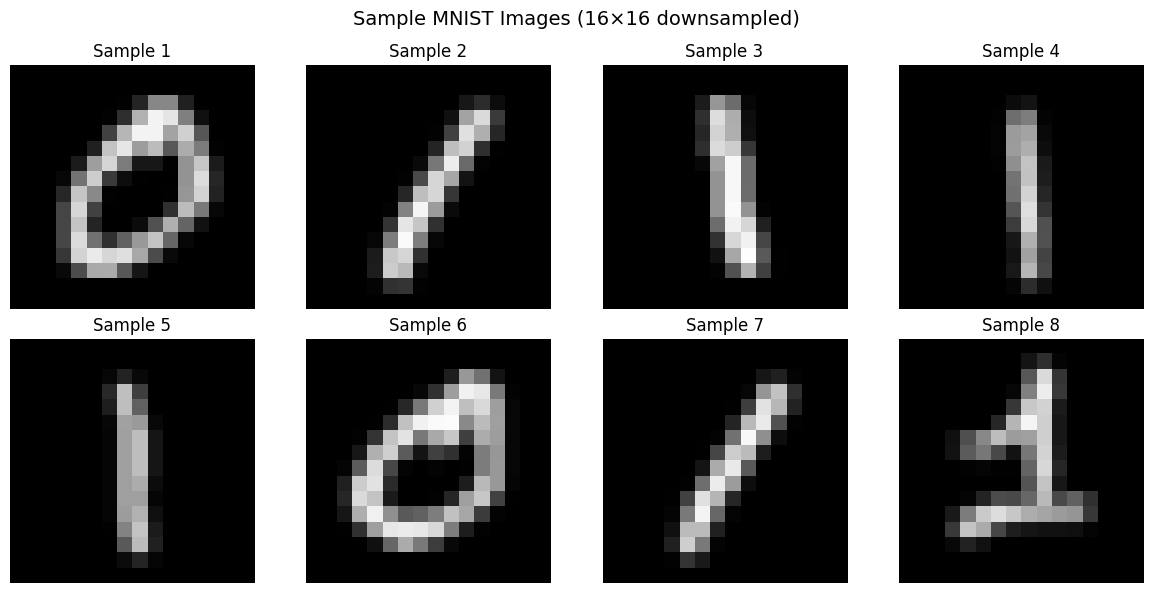

Dataset shape: (12665, 16, 16)
Image value range: [0.000, 1.000]


In [4]:
# Plot a few sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Sample MNIST Images (16×16 downsampled)', fontsize=14)

for i in range(8):
    row = i // 4
    col = i % 4
    ax = axes[row][col]
    
    # Plot the image
    ax.imshow(images[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Sample {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Dataset shape: {images.shape}")
print(f"Image value range: [{images.min():.3f}, {images.max():.3f}]")


In [6]:
def linear_beta_schedule(timesteps: int, start=0.0001, end=0.02):
    """Generates a linear schedule for beta values."""
    return jnp.linspace(start, end, timesteps)

@partial(jax.jit, static_argnames=['batch_size'])
def q_sample(r0_batch, t, alphas_cumprod, key, batch_size):
    """
    Samples from the forward process q(r_t | r_0) for a batch of images at a SINGLE timestep t.
    Note: t is now a scalar, applied to the whole batch.

    Args:
        r0_batch: The initial data samples (e.g., images). Shape: (B, H, W, C)
        t: A single timestep index (scalar integer).
        alphas_cumprod: The cumulative product of alpha values. Shape: (T,)
        key: JAX random key.
        batch_size: The number of samples in the batch.

    Returns:
        r_t_batch: The noised samples at the given timestep.
        epsilon_batch: The noise that was added to each sample.
    """
    # Get the pre-calculated cumulative alphas for the given timestep t
    # These values need to be reshaped to (B, 1, 1, 1) for broadcasting
    sqrt_alphas_cumprod_t = jnp.sqrt(alphas_cumprod[t])
    sqrt_one_minus_alphas_cumprod_t = jnp.sqrt(1. - alphas_cumprod[t])

    # Generate a batch of standard Gaussian noise
    epsilon_batch = jax.random.normal(key, shape=r0_batch.shape)

    # Apply the closed-form forward process formula
    r_t_batch = sqrt_alphas_cumprod_t * r0_batch + sqrt_one_minus_alphas_cumprod_t * epsilon_batch
    
    return r_t_batch, epsilon_batch

# --- 2. Physics-Informed Denoising Model (epsilon_theta) ---

def freespace_propagator(field, dx, wavelength, z):
    """Propagates a single 2D complex field."""
    H, W = field.shape
    fx = jnp.fft.fftfreq(W, dx)
    fy = jnp.fft.fftfreq(H, dx)
    FX, FY = jnp.meshgrid(fx, fy)
    H_kernel = jnp.exp(-1j * jnp.pi * wavelength * z * (FX**2 + FY**2))
    field_freq = jnp.fft.fft2(field)
    propagated_field_freq = field_freq * H_kernel
    return jnp.fft.ifft2(propagated_field_freq)

batched_propagator = jax.vmap(freespace_propagator, in_axes=(0, None, None, None))

def epsilon_theta_model(r_t_batch, theta_t, dx, wavelength, z):
    """
    The physics-informed model that predicts noise for a specific timestep t.
    Note: `theta_t` is now the parameters for a single timestep.
    """
    r_t_squeezed = r_t_batch.squeeze(axis=-1)
    propagated_field = batched_propagator(r_t_squeezed, dx, wavelength, z)
    slm_modulated_field = propagated_field * jnp.exp(1j * theta_t.squeeze(axis=-1))
    epsilon_pred = jnp.real(slm_modulated_field)[..., jnp.newaxis]
    return epsilon_pred

# --- 3. Loss Function and Training Step for a SINGLE Timestep ---

def loss_fn_for_t(theta_t, t, r0_batch, alphas_cumprod, key, p):
    """
    Calculates the MSE loss for a batch for a GIVEN timestep t.

    Args:
        theta_t: The model parameters for this specific timestep. Shape (H, W, 1)
        t: The current timestep (scalar integer).
        r0_batch: The batch of initial images.
        alphas_cumprod: Pre-calculated schedule values.
        key: JAX random key.
        p: A dictionary of physical and model parameters.
    """
    # 1. Get noisy samples and the true noise for timestep t
    r_t_batch, epsilon_batch = q_sample(r0_batch, t, alphas_cumprod, key, p['batch_size'])
    
    # 2. Get the model's prediction for the noise using theta_t
    epsilon_pred_batch = epsilon_theta_model(
        r_t_batch, theta_t, p['dx'], p['wavelength'], p['z']
    )
    
    # 3. Calculate the Mean Squared Error loss
    loss = jnp.mean((epsilon_batch - epsilon_pred_batch)**2)
    
    return loss


In [17]:
import numpy as np

# --- REPLACE THIS DUMMY DATA WITH YOUR `data.data` ---
num_images = 1000
image_height = 16
image_width = 28
# This is where you would load your data, e.g.:
# mnist_data_raw = data.data
mnist_data_raw = images
# --- END OF REPLACEMENT SECTION ---

# Preprocess the data
# a. Normalize the data to the range [-1, 1]
mnist_data_normalized = (mnist_data_raw / 127.5) - 1.0
# b. Add a channel dimension at the end -> (num_images, H, W, 1)
mnist_data = mnist_data_normalized[..., np.newaxis]

print(f"Loaded and preprocessed data. Shape: {mnist_data.shape}")

Loaded and preprocessed data. Shape: (12665, 16, 16, 1)


In [21]:
jnp.mean(images)

Array(0.12207425, dtype=float32)

In [18]:
# 1. Setup parameters
params = {
    'T': 1000,
    'batch_size': 100,
    'image_shape': (16, 16, 1),
    'dx': 1e-5,
    'wavelength': 532e-9,
    'z': 0.1,
    'learning_rate': 1e-3,
    'inner_training_steps': 100, # Number of optimization steps for EACH timestep t
}
# Create a master random key
key = jax.random.PRNGKey(0)

# 3. Pre-calculate schedule
betas = linear_beta_schedule(timesteps=params['T'])
alphas = 1. - betas
alphas_cumprod = jnp.cumprod(alphas, axis=0)

# 4. Initialize model parameters `thetas` for ALL timesteps
key, theta_key = jax.random.split(key)
thetas = jax.random.uniform(theta_key, shape=(params['T'], *params['image_shape']), minval=0, maxval=2*jnp.pi)

# 5. Initialize the optimizer
optimizer = optax.adam(learning_rate=params['learning_rate'])
opt_state = optimizer.init(thetas)

# 6. Define the JIT-compiled training step
@partial(jax.jit, static_argnames=['batch_size'])
def train_step(thetas, opt_state, t, r0_batch, key, batch_size):
    theta_t = thetas[t]
    loss_and_grad_fn = jax.value_and_grad(loss_fn_for_t)
    loss, grads = loss_and_grad_fn(theta_t, t, r0_batch, alphas_cumprod, key, params)
    full_grads = jnp.zeros_like(thetas).at[t].set(grads)
    updates, new_opt_state = optimizer.update(full_grads, opt_state, thetas)
    new_thetas = optax.apply_updates(thetas, updates)
    return new_thetas, new_opt_state, loss

In [19]:
# Physical parameters (SI units)
wavelength = 532e-9    # 532 nm light
z = 0.2               # propagation distance (m)
dx = 10e-6            # pixel size (m)

In [20]:
# 7. Run the sequential optimization loop
print("\n--- Starting Sequential Per-Timestep Optimization ---")
num_samples = mnist_data.shape[0]

for t in reversed(range(params['T'])):
    # Run an optimization loop for the current timestep t
    for step in range(params['inner_training_steps']):
        # Sample a new random batch from the dataset for each step
        key, step_key, batch_key = jax.random.split(key, 3)
        batch_indices = jax.random.choice(batch_key, num_samples, shape=(params['batch_size'],), replace=False)
        r0_batch = mnist_data[batch_indices]

        # Perform one training step
        thetas, opt_state, loss = train_step(thetas, opt_state, t, r0_batch, step_key, params['batch_size'])
        if step % 10 == 0 or step == params['inner_training_steps'] - 1:
            print(f"Finished optimizing for t = {t:4d}, step = {step:4d}, Loss for this step: {loss:.6f}")

    if t % 100 == 0 or t == params['T'] - 1:
        print(f"Finished optimizing for t = {t:4d}, Final Loss for this step: {loss:.6f}")

print("\n--- Optimization Complete ---")
print(f"Final shape of optimized parameters `thetas`: {thetas.shape}")


--- Starting Sequential Per-Timestep Optimization ---
Finished optimizing for t =  999, step =    0, Loss for this step: 1.493567
Finished optimizing for t =  999, step =   10, Loss for this step: 1.484486
Finished optimizing for t =  999, step =   20, Loss for this step: 1.535650
Finished optimizing for t =  999, step =   30, Loss for this step: 1.486213
Finished optimizing for t =  999, step =   40, Loss for this step: 1.476249
Finished optimizing for t =  999, step =   50, Loss for this step: 1.474255
Finished optimizing for t =  999, step =   60, Loss for this step: 1.512019
Finished optimizing for t =  999, step =   70, Loss for this step: 1.506745
Finished optimizing for t =  999, step =   80, Loss for this step: 1.506133
Finished optimizing for t =  999, step =   90, Loss for this step: 1.499263
Finished optimizing for t =  999, step =   99, Loss for this step: 1.513076
Finished optimizing for t =  999, Final Loss for this step: 1.513076
Finished optimizing for t =  998, step =

KeyboardInterrupt: 